# Investigate RS.LUNR_Test.dcm: 
**CTV Cavity -> Cavity**

This notebook reproduces the relationship pipeline for the DICOM RT Structure 
Set `RS.LUNR_Test.dcm` and documents the per-slice relations that are 
merged into the final relation.

## 1) Load DICOM file and build StructureSet

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import shapely

from contours import ContourPoints
from debug_tools import make_vertical_cylinder, circle_points
from contour_plotting import plot_ab, plot_roi_slice
from relations import *
from dicom import DicomStructureFile
from structure_set import StructureSet
from region_slice import empty_structure

INFO:metrics.base:Registered calculator: orthogonal_margins (OrthogonalMarginsCalculator)
INFO:metrics.base:Registered calculator: minimum_margin (MinimumMarginCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


In [2]:
# Ensure src imports work regardless of notebook working directory
cwd = Path.cwd().resolve()
dicom_path = cwd / 'Tests' / 'RS.LUNR_Test.LUNR.dcm'
print('Found File: ', dicom_path.exists())  # Check that the path is correct
dicom_path

Found File:  True


WindowsPath("D:/OneDrive - Queen's University/Python/Projects/StructureRelations/Tests/RS.LUNR_Test.LUNR.dcm")

In [3]:
dicom_file = DicomStructureFile(top_dir=cwd / 'Tests',
                                file_path=dicom_path)
structure_set = StructureSet(
    dicom_structure_file=dicom_file,
    include_structures=['Lung R', 'IGTV', 'opt PTV LT',
                        #'ITV', 'PTV',
                        'opt ITV RT', 'opt ITV LT',
                        #'opt PTV RT'
                        ]
    )

print(f'Loaded: {dicom_path}')
print(f'Structures found: {len(structure_set.structures)}')
print(f'Relationship graph edges: {structure_set.relationship_graph.number_of_edges()}')

INFO:dicom:Successfully loaded DICOM dataset from RS.LUNR_Test.LUNR.dcm
INFO:dicom:Extracted 2304 contours from 29 ROIs
INFO:dicom:Found 0 frame-of-reference matches and 0 other matches for structure set RS.LUNR_Test.LUNR.dcm
INFO:dicom:Calculated resolution from structure 'BODY': 0.050 cm/pixel
INFO:structure_set:Building StructureSet from 2304 contour points (unit: cm)
INFO:structure_set:Skipping structure BODY (1) due to filters
INFO:structure_set:Skipping structure $BrachialPlexusR (4) due to filters
INFO:structure_set:Skipping structure $BronchialTree (5) due to filters
INFO:structure_set:Skipping structure $Chestwall_R (6) due to filters
INFO:structure_set:Skipping structure GTV PET (30) due to filters
INFO:structure_set:Adding structure IGTV (31)
INFO:structure_set:Skipping structure ITV (32) due to filters
INFO:structure_set:Skipping structure PTV (33) due to filters
INFO:structure_set:Skipping structure Aorta (36) due to filters
INFO:structure_set:Skipping structure Esophagus 

Loaded: D:\OneDrive - Queen's University\Python\Projects\StructureRelations\Tests\RS.LUNR_Test.LUNR.dcm
Structures found: 5
Relationship graph edges: 10


In [4]:
ROI_TABLE = pd.DataFrame([
    {'roi': roi, 'name': structure.name}
    for roi, structure in structure_set.structures.items()
]).sort_values('name').reset_index(drop=True)
display(ROI_TABLE)


,roi,name
0,31,IGTV
1,51,Lung R
2,70,opt ITV LT
3,69,opt ITV RT
4,72,opt PTV LT


## 2. Useful functions

### a) Functions to map target structure names and ROI numbers

In [5]:
def find_roi_by_name(target_name: str, table: pd.DataFrame) -> int:
    exact = table.loc[table['name'] == target_name, 'roi']
    if not exact.empty:
        return int(exact.iloc[0])

    normalized = table['name'].str.lower().str.strip()
    target_norm = target_name.lower().strip()

    exact_norm = table.loc[normalized == target_norm, 'roi']
    if not exact_norm.empty:
        return int(exact_norm.iloc[0])

    contains = table.loc[normalized.str.contains(target_norm, regex=False), 'roi']
    if len(contains) == 1:
        return int(contains.iloc[0])

    raise ValueError(
        f'Could not uniquely resolve ROI for {target_name}. '
        'Check roi_table for actual names.'
    )


### b) Function to identify relationships one each slice

In [6]:
def get_slice_relations(structure_a, structure_b):
    slices_a = set(structure_a.region_table['SliceIndex'])
    slices_b = set(structure_b.region_table['SliceIndex'])
    used_slices = slices_a | slices_b

    mask_a = structure_a.region_table.SliceIndex.isin(used_slices) & ~structure_a.region_table.Empty
    mask_b = structure_b.region_table.SliceIndex.isin(used_slices) & ~structure_b.region_table.Empty

    regions_a = structure_a.region_table.loc[mask_a, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions_b = structure_b.region_table.loc[mask_b, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions = regions_a.join(regions_b, how='outer', lsuffix='_a', rsuffix='_b').sort_index()

    cumulative = DE27IM()
    slice_rows = []

    for slice_index, row in regions.iterrows():
        region_a = row['RegionSlice_a']
        region_b = row['RegionSlice_b']

        relation = DE27IM(region_a, region_b, tolerance=structure_set.tolerance)
        relation_type = relation.identify_relation()

        cumulative.merge(relation)
        cumulative_type = cumulative.identify_relation()

        slice_rows.append({
            'slice_index': float(slice_index),
            'a_present': not empty_structure(region_a),
            'b_present': not empty_structure(region_b),
            'slice_relation_type': relation_type.relation_type if relation_type else None,
            'slice_relation_label': relation_type.label if relation_type else None,
            'slice_de27im_bits': relation.relation,
            'slice_de27im_int': relation.int,
            'cumulative_relation_type': cumulative_type.relation_type if cumulative_type else None,
            'cumulative_relation_label': cumulative_type.label if cumulative_type else None,
            'cumulative_de27im_bits': cumulative.relation,
            'cumulative_de27im_int': cumulative.int,
        })

    slice_relation_df = pd.DataFrame(slice_rows).sort_values('slice_index').reset_index(drop=True)
    slice_relation_df.set_index('slice_index', inplace=True)
    return slice_relation_df, cumulative

### c) Functions to plot structures

In [7]:
def plot_slice_ax(ax, slice_idx, structure_a, structure_b, slice_relation_df):
    # Get the RegionSlice objects for both structures at this slice
    region_a = structure_a.get_slice(slice_idx)
    region_b = structure_b.get_slice(slice_idx)

    try:
        plot_ab(region_a, region_b, axes=ax, add_axis=True)
        # Get the relation type for this slice from our dataframe
        slice_rel = slice_relation_df[slice_relation_df['slice_index'] == slice_idx]
        if not slice_rel.empty:
            rel_label = slice_rel.iloc[0]['slice_relation_label']
            ax.set_title(
                f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}\n'
                f'Slice relation: {rel_label}',
                fontsize=12
            )
        else:
            ax.set_title(f'z={slice_idx:.2f}\n{structure_a.name} vs {structure_b.name}', fontsize=12)
    except Exception as err:
        ax.text(0.5, 0.5, f'Error plotting slice {slice_idx}:\n{str(err)}',
            ha='center', va='center')
        ax.set_title(f'z={slice_idx:.2f}')


In [8]:
def plot_single_slice(slice_idx, structure_a, structure_b, slice_relation_df):
    # Create figure and plot
    fig, ax = plt.subplots(figsize=(4, 4))
    try:
        plot_slice_ax(ax, slice_idx, structure_a, structure_b, slice_relation_df)
    except Exception as err:
        ax.text(0.5, 0.5, f'Error plotting slice {slice_idx}:\n{str(err)}',
            ha='center', va='center')
        ax.set_title(f'z={slice_idx:.2f}')

    plt.tight_layout()
    plt.show()

    print('\n🔍 Plot Legend:')
    print('  Blue area: Only in A (PTV Total)')
    print('  Green area: Only in B (GTV 1 xxGy)')
    print('  Orange area: Intersection (both A and B)')
    print('  Gray dashed lines: Origin (X=0, Y=0)')

## 3) Relationship validation table: Expected vs Actual

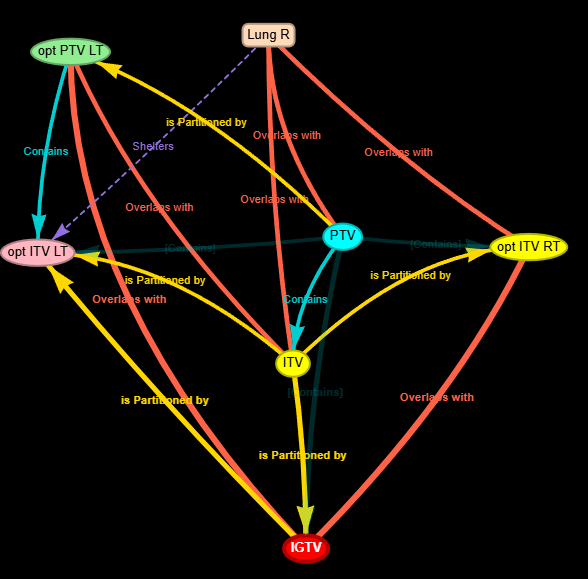

|Structure_B|Lung R|PTV|opt PTV LT|ITV|opt ITV RT|opt ITV LT|IGTV|
|-----------|-|-|-|-|-|-|-|
|Lung R|=|∩|?|∩|∩|△|?|
|PTV|∩|=|⊗|⊃|⊃|⊃|⊃|
|opt PTV LT|?|⊕|=|∩|∅|⊃|∩|
|ITV|∩|⊂|∩|=|⊗|⊗|⊗|
|opt ITV RT|∩|[⊂]|∅|⊕|=|∅|∩|
|opt ITV LT|△|[⊂]|⊂|⊕|∅|=|⊕|
|IGTV|?|[⊂]|∩|⊕|∩|⊗|=|

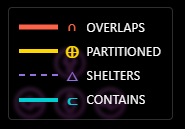

The Unknown relationships appears to be due to combining Confines and shelters regions

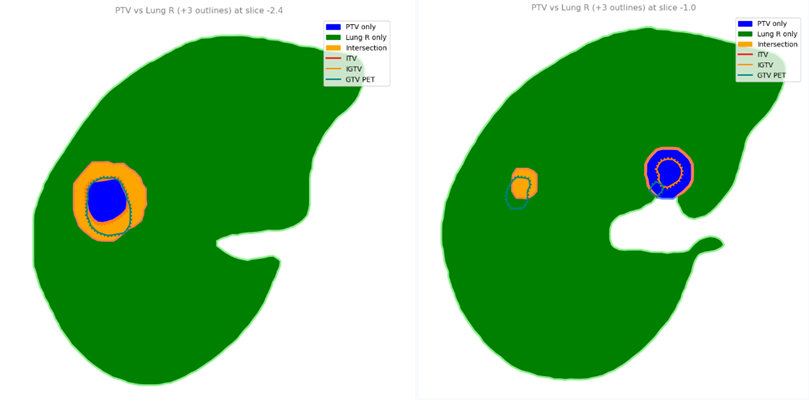

In [9]:
# Define expected relationships based on clinical/geometric requirements
expected_relations = {
    #('Lung R', 'PTV'): 'Overlaps with',
    #('Lung R', 'opt PTV RT'): 'Overlaps with',
    #('Lung R', 'ITV'): 'Overlaps with',
    ('Lung R', 'IGTV'): '{Confines & Shelters}',
    ('Lung R', 'opt ITV RT'): 'Overlaps with',
    ('Lung R', 'opt PTV LT'): 'Overlaps with',
    ('Lung R', 'opt ITV LT'): 'Shelters',
    #('PTV', 'opt PTV RT'): 'is Partitioned by',
    #('PTV', 'ITV'): 'Contains',
    #('PTV', 'IGTV'): 'Contains',
    #('PTV', 'opt ITV RT'): 'Contains',
    #('PTV', 'opt PTV LT'): 'is Partitioned by',
    #('PTV', 'opt ITV LT'): 'Contains',
    #('opt PTV RT', 'ITV'): 'Overlaps with',
    #('opt PTV RT', 'IGTV'): 'Overlaps with',
    #('opt PTV RT', 'opt ITV RT'): 'Contains',
    #('opt PTV RT', 'opt PTV LT'): 'is Disjoint from',
    #('opt PTV RT', 'opt ITV LT'): 'is Disjoint from',
    #('ITV', 'IGTV'): 'is Partitioned by',
    #('ITV', 'opt ITV RT'): 'is Partitioned by',
    #('ITV', 'opt PTV LT'): 'Overlaps with',
    #('ITV', 'opt ITV LT'): 'is Partitioned by',
    ('IGTV', 'opt ITV RT'): 'Overlaps with',
    ('IGTV', 'opt PTV LT'): 'Overlaps with',
    ('IGTV', 'opt ITV LT'): 'is Partitioned by',
    ('opt ITV RT', 'opt PTV LT'): 'is Disjoint from',
    ('opt ITV RT', 'opt ITV LT'): 'is Disjoint from',
    ('opt PTV LT', 'opt ITV LT'): 'Contains',
    }


In [10]:
# Collect results
comparison_rows = []
for (name_a, name_b), expected_type in expected_relations.items():
    try:
        roi_a = find_roi_by_name(name_a, ROI_TABLE)
        roi_b = find_roi_by_name(name_b, ROI_TABLE)
    except ValueError as err:
        print(f'Error finding ROI for {name_a} or {name_b}: {err}')
        continue

    rel = structure_set.get_relationship(roi_a, roi_b)
    actual_type = rel.relationship_type.label if rel and rel.relationship_type else 'Unknown'

    is_match = (expected_type == actual_type)

    comparison_rows.append({
        'Structure A': name_a,
        'Structure B': name_b,
        'Expected': expected_type,
        'Actual': actual_type,
        'Match': '✅' if is_match else '❌',
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

# Show mismatches
mismatches = comparison_df[comparison_df['Match'] == '❌']
print(f'\n⚠️ INCORRECT RELATIONSHIPS: {len(mismatches)} out of {len(comparison_df)}')
if len(mismatches) > 0:
    display(mismatches[['Structure A', 'Structure B', 'Expected', 'Actual']])

print(f'Default tolerance is {structure_set.tolerance}')

,Structure A,Structure B,Expected,Actual,Match
0,Lung R,IGTV,{Confines & Shelters},Unknown,❌
1,Lung R,opt ITV RT,Overlaps with,Overlaps with,✅
2,Lung R,opt PTV LT,Overlaps with,Unknown,❌
3,Lung R,opt ITV LT,Shelters,Shelters,✅
4,IGTV,opt ITV RT,Overlaps with,Overlaps with,✅
5,IGTV,opt PTV LT,Overlaps with,Overlaps with,✅
6,IGTV,opt ITV LT,is Partitioned by,is Partitioned by,✅
7,opt ITV RT,opt PTV LT,is Disjoint from,is Disjoint from,✅
8,opt ITV RT,opt ITV LT,is Disjoint from,is Disjoint from,✅
9,opt PTV LT,opt ITV LT,Contains,Contains,✅



⚠️ INCORRECT RELATIONSHIPS: 2 out of 10


,Structure A,Structure B,Expected,Actual
0,Lung R,IGTV,{Confines & Shelters},Unknown
2,Lung R,opt PTV LT,Overlaps with,Unknown


Default tolerance is 0.05


## Check on specific relationship:
- Lung R -> IGTV

In [11]:
target_a_name = 'Lung R'
target_b_name = 'IGTV'

roi_a = find_roi_by_name(target_a_name, ROI_TABLE)
roi_b = find_roi_by_name(target_b_name, ROI_TABLE)

print(f'A: {structure_set.structures[roi_a].name} (ROI {roi_a})')
print(f'B: {structure_set.structures[roi_b].name} (ROI {roi_b})')
print('\n')

relationship = structure_set.get_relationship(roi_a, roi_b)

print(f'Tolerance used for relation calculations: {structure_set.tolerance}')
print(f'Final relation type: {relationship.relationship_type.label}')
print(f'Final relation type key: {relationship.relationship_type.relation_type}')
print(f'Final DE27IM bits: {relationship.de27im.relation}')

structure_a = structure_set.structures[roi_a]
structure_b = structure_set.structures[roi_b]

A: Lung R (ROI 51)
B: IGTV (ROI 31)


Tolerance used for relation calculations: 0.05
Final relation type: has an Unknown relationship with
Final relation type key: UNKNOWN
Final DE27IM bits: 011111111111001111111001001


In [12]:
relationship.__dict__

{'de27im': <DE27IM>: 011111111111001111111001001,
 'is_identical': False,
 'is_logical': False,
 'intermediate_structures': [],
 'metrics': None,
 '_override_type': None,
 'per_region_relations': {('51A',
   '31A'): <DE27IM>: 011111111111001001111001001,
  ('51A', '31B'): <DE27IM>: 001001111001001111111001001}}

In [13]:
relationship.region_relationship_types

{('51A', '31A'): RelationshipType(CONFINES),
 ('51A', '31B'): RelationshipType(SHELTERS)}

In [14]:
structure_set.get_relationship(roi_a, roi_b).describe_relationship()

{'consolidated_label': '{Confines & Shelters}',
 'consolidated_type': 'UNKNOWN',
 'has_multiple_regions': True,
 'per_region': [{'region_a': '51A',
   'region_b': '31A',
   'label': 'Confines',
   'type': 'CONFINES'},
  {'region_a': '51A',
   'region_b': '31B',
   'label': 'Shelters',
   'type': 'SHELTERS'}],
 'summary': [{'label': 'Confines', 'type': 'CONFINES', 'count': 1},
  {'label': 'Shelters', 'type': 'SHELTERS', 'count': 1}]}

# ERROR consolidated_label is '{Confines & Shelters}',
but display is showing 'Unknown' 

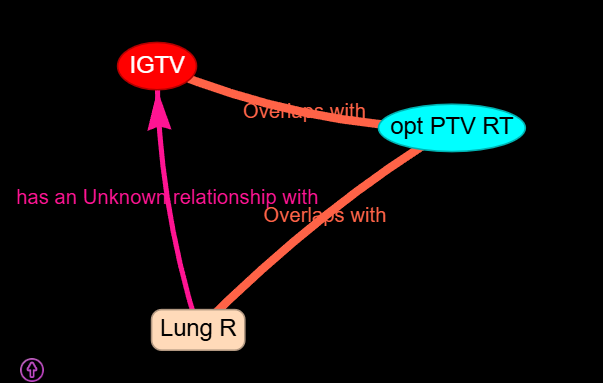

In [15]:
target_a_name = 'Lung R'
target_b_name = 'opt PTV LT'
roi_a = find_roi_by_name(target_a_name, ROI_TABLE)
roi_b = find_roi_by_name(target_b_name, ROI_TABLE)
structure_a = structure_set.structures[roi_a]
structure_b = structure_set.structures[roi_b]
relationship = structure_set.get_relationship(roi_a, roi_b)
structure_set.get_relationship(roi_a, roi_b).describe_relationship()

{'consolidated_label': '',
 'consolidated_type': 'UNKNOWN',
 'has_multiple_regions': False,
 'per_region': [{'region_a': '51A',
   'region_b': '72A',
   'label': 'Overlaps with',
   'type': 'OVERLAPS'}],
 'summary': [{'label': 'Overlaps with', 'type': 'OVERLAPS', 'count': 1}]}

# ERROR Summary is showing Overlaps but Consolidated is showing Unknown

### 5a) Slice-by-slice relations and cumulative merge

This mirrors `StructureShape.relate()`:
- iterate union of non-empty slices for A and B
- compute per-slice `DE27IM(region_a, region_b, tolerance=structure_set.tolerance)`
- merge with bitwise OR into cumulative DE27IM

In [16]:
slice_relation_df, cumulative = get_slice_relations(structure_a, structure_b)

#### Consistency checks

In [17]:
print(f'Tolerance used for relation calculations: {structure_set.tolerance}')
print('StructureSet final relation type:', relationship.relationship_type.relation_type)
print('Reconstructed final relation type:', cumulative.identify_relation().relation_type)
print('StructureSet DE27IM bits       :', relationship.de27im.relation)
print('Reconstructed DE27IM bits      :', cumulative.relation)

assert relationship.de27im.int == cumulative.int, (
    'Mismatch between StructureSet final relation and reconstructed cumulative relation.'
)
print('✅ Reconstructed cumulative relation matches StructureSet output.')

Tolerance used for relation calculations: 0.05
StructureSet final relation type: UNKNOWN
Reconstructed final relation type: UNKNOWN
StructureSet DE27IM bits       : 011111111111111111111001001
Reconstructed DE27IM bits      : 011111111111111111111001001
✅ Reconstructed cumulative relation matches StructureSet output.


#### Relationships on individual slices where both structures are present

In [18]:
both_present = slice_relation_df[slice_relation_df['a_present'] & slice_relation_df['b_present']].copy()
column_selector = ['slice_relation_label', 'cumulative_relation_label', 'slice_de27im_bits', 'cumulative_de27im_bits']
display(both_present[column_selector])


,slice_relation_label,cumulative_relation_label,slice_de27im_bits,cumulative_de27im_bits
slice_index,,,,
-1.5,NaN,NaN,010010000000000000000000000,011011001001001001001001001
-1.4,Confines,Confines,011111111111001001111001001,011111111111001001111001001
-1.3,NaN,Confines,000000000000000000000000000,011111111111001001111001001
-1.2,Borders,NaN,011111111011111111111001001,011111111111111111111001001
-1.1,Borders,NaN,011111111011111111111001001,011111111111111111111001001
-1.0,Borders,NaN,011111111011111111111001001,011111111111111111111001001
-0.8,Borders,NaN,011011111011011111111001001,011111111111111111111001001
-0.6,Borders,NaN,011011111011011111111001001,011111111111111111111001001
-0.4,Borders,NaN,011011111011011111111001001,011111111111111111111001001


|slice|slice relation|cumulative relation|slice de27im|cumulative de27im|
|-----------|--------------------|-------------------------|-----------------|----------------------|
|-1.4       |Confines            |Confines                 |011111111111001001111001001|011111111111001001111001001|
|-1.2       |Borders             |NaN                      |011111111011111111111001001|011111111111111111111001001|
|-0.8       |Borders             |NaN                      |011011111011011111111001001|011111111111111111111001001|


# ERROR Relationship on slice -1.4 should not be **Confines** because The hole that structure B is in should be am Open Hole.

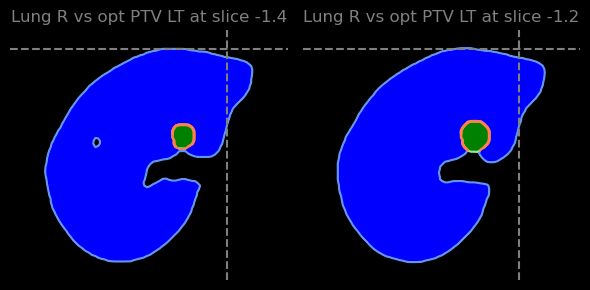

In [19]:
# Create figure and plot
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
slice_idx = -1.4
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[0], tolerance=0.1,
               plot_mode='relationship', show_legend=False)
slice_idx = -1.2
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[1], tolerance=0.1,
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()


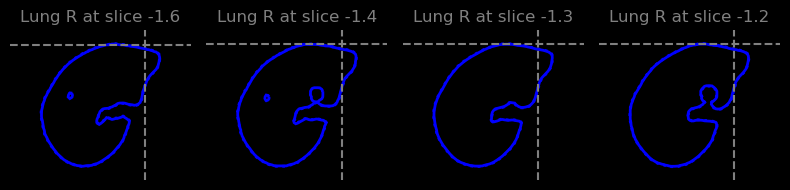

In [20]:
# Create figure and plot
fig, ax = plt.subplots(1, 4, figsize=(8, 2))
slice_idx = -1.6
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name],
               add_axis=True, axes=ax[0], tolerance=0.1,
               show_legend=False)
slice_idx = -1.4
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name],
               add_axis=True, axes=ax[1], tolerance=0.1,
               show_legend=False)
slice_idx = -1.3
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name],
               add_axis=True, axes=ax[2], tolerance=0.1,
               show_legend=False)
slice_idx = -1.2
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name],
               add_axis=True, axes=ax[3], tolerance=0.1,
               show_legend=False)
plt.tight_layout()
plt.show()

In [21]:
contour_lookup = structure_a.contour_lookup
selected_slices = ((contour_lookup['SliceIndex'] >= -1.6) &
                   (contour_lookup['SliceIndex'] <= -1.2))
contour_lookup[selected_slices]

,ROI,SliceIndex,HoleType,Interpolated,Boundary,ContourIndex,RegionIndex,Label
71,51,-1.6,None,False,False,100,51A,"(51, -1.6, 100)"
72,51,-1.6,Closed,False,False,101,51B,"(51, -1.6, 101)"
144,51,-1.5,Closed,True,True,173,51C,"(51, -1.5, 173)"
145,51,-1.5,None,True,False,174,51A,"(51, -1.5, 174)"
153,51,-1.5,None,True,False,226,51A,"(51, -1.5, 226)"
154,51,-1.5,Closed,True,False,227,51B,"(51, -1.5, 227)"
73,51,-1.4,None,False,False,102,51A,"(51, -1.4, 102)"
74,51,-1.4,Closed,False,False,103,51C,"(51, -1.4, 103)"
75,51,-1.4,Closed,False,False,104,51B,"(51, -1.4, 104)"
146,51,-1.3,Closed,True,True,175,51B,"(51, -1.3, 175)"


**Why is the hole not appearing in the interpolated slice (-1.3)?**
- A hole (*51B*) is present on slice -1.3, but it is in the same region as the 
    hole on slice -1.6
- The missing hole is for region *51C* and should be a boundary hole on slice -1.3
- At the same time, no holes are appearing on the interpolated slice -1.3.

# Working Here

## Reproduce with test structure
- Lets try reproducing this with a test structure that has a similar hole pattern to see if we can identify the issue with the interpolation.
- The hole must be closed on one end.
- On the other end it must be open, but do so by shifting laterally beyond the 
    external border.

**Status:**
- I am able to reproduce the relationship issue
- The hole being treated as closed when it is open.
- For the relationship issue, I am getting a relationship of "Confines" on 
    slice -1. However, it is an "Open Hole" so it should report Boundary.
- I need to figure our why the hole is being treated as closed when it is open. 
- This may be related to a bug that was reported earlier and not yet addressed.
- The issue appears to only occur when the hole is only one slice thick.
- When the diagonal cylinder extends further in the hole type is correct and 
    the relationship is Boundary as expected.

## TODO:
1. Create test methods in test_multi_region_relations.py to document the verify 
    fixes for this issue.
2. Investigate the root cause of holes being treated as closed when they are open. 
3. Investigate the root cause of missing holes on interpolated slices.
4. Fix issue that Relationship Summary is showing **Overlaps** but Consolidated 
    Relationship is showing **Unknown**
4. Fix issue that diagram is showing **Unknown** when is should show 
    **{Confines & Shelters}**.


## Copilot Ask
*Please describe the process for identifying which holes are open and which are closed*

### How Open vs. Closed Holes Are Identified

The process runs in `set_hole_type()` in contour_graph.py, called as the last step of `build_contour_graph()`.

#### Step 1 – Initial `hole_type` assignment (in `Contour.__init__` / `compare_with_existing_contours`)

When a `Contour` is created, `hole_type` defaults to `'None'`. In `compare_with_existing_contours()` (contours.py), if the new polygon is geometrically *within* an existing non-hole contour on the same slice, it is marked `is_hole = True` and `hole_type = 'Unknown'`. All holes start as `Unknown`.

#### Step 2 – Boundary contour interpolation (`add_boundary_contours`)

Before hole typing can be determined, interpolated boundary contours are injected at both ends of every region (one slice beyond where the region starts/ends). This is what creates the "boundary" contours used in Step 3.

#### Step 3 – Region assignment (`set_enclosed_regions`)

Weakly-connected components of the graph are found; each component is a distinct 3D region and gets a `region_index` label (e.g. `51B`, `51C`).

#### Step 4 – `set_hole_type` determines Open vs. Closed

For every hole contour that sits on a **boundary slice**:

1. **Find the "beyond" slice**: identify which neighbor of `slice_sequence` is *not* the interior neighbor — i.e., the slice on the far side of the boundary, outside the region.
2. **Look for containing contours**: collect all non-hole contours of the same ROI on that beyond-slice.
3. **Test containment**: if any of those contours `contains()` the boundary hole polygon → that boundary is **Closed** (the hole is capped).
4. **If no containing contour exists** (or there is no beyond-slice at all) → that boundary is **Open** (the hole opens to the exterior).

The rule for aggregating across multiple boundary slices of the same region:
- **Open wins**: if *any* boundary is open, the whole region is `'Open'`.
- **Closed only if all boundaries are closed**: `'Closed'` is only set if no open boundary has been found yet.

Finally, the resolved `hole_type` (`'Open'`, `'Closed'`, or `'Unknown'` if the region had no boundary hole contours) is written back to every `Contour` in that region.

---

#### Known Issue (from your notebook)

The bug you identified — a hole being classified as `'Closed'` when it should be `'Open'` — occurs in the single-slice-thick hole case. On that slice, the boundary contour is interpolated, and the "beyond" test checks for a containing contour one step outside. If the hole region spans only one real slice, the boundary contour's `region_index` may be misassigned or the beyond-slice lookup may find the outer cylinder's contour on that adjacent slice and incorrectly conclude the hole is closed.

In [22]:
def find_coords_idx(roi, slice, slice_list):
    for idx, contour in enumerate(slice_list):
        if contour['ROI'] == roi and contour['Slice'] == slice:
            return idx
    raise ValueError(f'No contour found for ROI {roi} at slice {slice}')

In [ ]:
def make_short_overlapping_boundary_test():
    # Outer cylinder with diagonal cylinder that carves out a region from the
    # outer cylinder. The diagonal cylinder is only surrounded by the outer
    # cylinder on one slice.
    slice_spacing = 1
    # Body structure defines slices in use
    #body = make_vertical_cylinder(roi_num=0, radius=12, length=16, offset_z=0,
    #                                spacing=slice_spacing)
    roi_num = 1
    num_points = 100

    # Start with the outer cylinder and subtract the inner hole to create a
    # hollow shell
    slice_list = make_vertical_cylinder(roi_num=1, radius=6, length=10,
                                            spacing=slice_spacing,
                                            num_points=num_points)
    confined_circle = circle_points(radius=3, offset_x=3, offset_y=0,
                                    num_points=num_points)
    # Add the confined circle as a hole
    slice_list.append(ContourPoints(confined_circle, roi_num, slice_index=-1))
    # Add the confined circle as seperate structure
    slice_list.append(ContourPoints(confined_circle, roi_num+1, slice_index=-1))


    x_offset = 3.0
    for slice in range(0, 4):
        x_offset += 1
        # Create the shifted inner circle
        inner_circle = circle_points(radius=3, offset_x=x_offset, offset_y=0,
                                    num_points=num_points)
        inner_polygon = shapely.Polygon(inner_circle)
        # Find the corresponding outer polygon for this slice
        i = find_coords_idx(roi_num, slice, slice_list)
        outer_poly  = shapely.Polygon(slice_list[i]['Points'])
        # if the inner polygon overlaps the outer one, subtract the inner polygon
        # from the outer polygon to create a crescent shape
        if inner_polygon.overlaps(outer_poly):
            final_polygon = outer_poly - inner_polygon
            final_coordinates = shapely.get_coordinates(final_polygon.exterior)
            # replace the original contour with the new crescent shape
            slice_list[i] = ContourPoints(final_coordinates, roi_num, slice_index=slice)
        # Add the inner circle as a seperate structure
        slice_list.append(ContourPoints(inner_circle, roi_num+1, slice_index=slice))
    return slice_list

Slice 0: Inner circle overlaps with outer polygon as expected.
Slice 1: Inner circle overlaps with outer polygon as expected.
Slice 2: Inner circle overlaps with outer polygon as expected.
Slice 3: Inner circle overlaps with outer polygon as expected.


In [ ]:
tolerance=0.1
slice_list = make_short_overlapping_boundary_test()
structure_set = StructureSet(slice_list, tolerance=tolerance)
structure_set.get_relationship(1, 2).describe_relationship()


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: has an Unknown relationship with
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


{'consolidated_label': '',
 'consolidated_type': 'UNKNOWN',
 'has_multiple_regions': False,
 'per_region': [{'region_a': '1A',
   'region_b': '2A',
   'label': 'has an Unknown relationship with',
   'type': 'UNKNOWN'}],
 'summary': [{'label': 'has an Unknown relationship with',
   'type': 'UNKNOWN',
   'count': 1}]}

In [35]:
structure_a = structure_set.structures[1]
structure_b = structure_set.structures[2]
contour_lookup = structure_a.contour_lookup
selected_slices = ((contour_lookup['SliceIndex'] >= -2.0) &
                   (contour_lookup['SliceIndex'] <= 0.0))
contour_lookup[selected_slices]

,ROI,SliceIndex,HoleType,Interpolated,Boundary,ContourIndex,RegionIndex,Label
3,1,-2.0,None,False,False,238,1A,"(1, -2.0, 238)"
13,1,-1.5,Closed,True,True,248,1B,"(1, -1.5, 248)"
14,1,-1.5,None,True,False,249,1A,"(1, -1.5, 249)"
4,1,-1.0,None,False,False,239,1A,"(1, -1.0, 239)"
5,1,-1.0,Closed,False,False,240,1B,"(1, -1.0, 240)"
6,1,0.0,None,False,False,241,1A,"(1, 0.0, 241)"


In [27]:
structure_a = structure_set.structures[1]
structure_b = structure_set.structures[2]
slice_relation_df, cumulative = get_slice_relations(structure_a, structure_b)

both_present = slice_relation_df[slice_relation_df['a_present'] & slice_relation_df['b_present']].copy()
column_selector = ['slice_relation_label', 'cumulative_relation_label', 'slice_de27im_bits', 'cumulative_de27im_bits']
display(both_present[column_selector])

,slice_relation_label,cumulative_relation_label,slice_de27im_bits,cumulative_de27im_bits
slice_index,,,,
-1.5,NaN,NaN,010010000000000000000000000,011011001001001001001001001
-1.0,Confines,Confines,001011101111011001111011001,011011101111011001111011001
0.0,Borders,NaN,011111111011111111111111111,011111111111111111111111111
1.0,Borders,NaN,011111111011111111111111111,011111111111111111111111111
2.0,Borders,NaN,011111111011111111111111111,011111111111111111111111111
3.0,Borders,NaN,011111111011111111111111111,011111111111111111111111111
3.5,NaN,NaN,010000000000000000000000000,011111111111111111111111111


-1.0<br>
**Confines**<br>
`001 111 111`<br>
`011 011 011`<br>
`101 001 001`<br>


When the diagonal cylinder extends further in the hole type is correct and the 
relationship is Boundary as expected.

In [40]:
def make_long_overlapping_boundary_test():
    # Outer cylinder with diagonal cylinder that carves out a region from the
    # outer cylinder. The diagonal cylinder is surrounded by the outer
    # cylinder on several slices.
    slice_spacing = 1
    roi_num = 1
    num_points = 100

    # Start with the outer cylinder and subtract the inner hole to create a
    # hollow shell
    slice_list = make_vertical_cylinder(roi_num=1, radius=6, length=10,
                                            spacing=slice_spacing,
                                            num_points=num_points)
    confined_circle = circle_points(radius=3, offset_x=3, offset_y=0,
                                    num_points=num_points)
    # Add the confined circle as a hole
    slice_list.append(ContourPoints(confined_circle, roi_num, slice_index=-1))
    # Add the confined circle as seperate structure
    slice_list.append(ContourPoints(confined_circle, roi_num+1, slice_index=-1))


    x_offset = 0.0
    for slice in range(-3, 4):
        x_offset += 1
        # Create the shifted inner circle
        inner_circle = circle_points(radius=3, offset_x=x_offset, offset_y=0,
                                    num_points=num_points)
        inner_polygon = shapely.Polygon(inner_circle)
        # Find the corresponding outer polygon for this slice
        i = find_coords_idx(roi_num, slice, slice_list)
        outer_poly  = shapely.Polygon(slice_list[i]['Points'])
        if outer_poly.contains(inner_polygon):
            # If the outer polygon contains the inner one, add a hole contour
            # to the list
                slice_list.append(ContourPoints(inner_circle, roi_num,
                                                slice_index=slice))
        elif outer_poly.overlaps(inner_polygon):
            # if the outer polygon overlaps the inner one, subtract the inner
            # polygon from the outer polygon to create a crescent shape
            final_polygon = outer_poly - inner_polygon
            final_coordinates = shapely.get_coordinates(final_polygon.exterior)
            # replace the original contour with the new crescent shape
            slice_list[i] = ContourPoints(final_coordinates, roi_num, slice_index=slice)
        # Add the inner circle as a seperate structure
        slice_list.append(ContourPoints(inner_circle, roi_num+1, slice_index=slice))
    return slice_list

In [41]:
tolerance=0.1
slice_list = make_long_overlapping_boundary_test()
structure_set = StructureSet(slice_list, tolerance=tolerance)
structure_set.get_relationship(1, 2).describe_relationship()

structure_a = structure_set.structures[1]
structure_b = structure_set.structures[2]
structure_a.contour_lookup


INFO:structure_set:Adding structure Structure_1 (1)


INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Borders
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete


,ROI,SliceIndex,HoleType,Interpolated,Boundary,ContourIndex,RegionIndex,Label
15,1,-5.25,None,True,True,308,1A,"(1, -5.25, 308)"
0,1,-5.00,None,False,False,293,1A,"(1, -5.0, 293)"
1,1,-4.00,None,False,False,294,1A,"(1, -4.0, 294)"
16,1,-3.50,Open,True,True,309,1B,"(1, -3.5, 309)"
17,1,-3.50,None,True,False,310,1A,"(1, -3.5, 310)"
2,1,-3.00,None,False,False,295,1A,"(1, -3.0, 295)"
3,1,-3.00,Open,False,False,296,1B,"(1, -3.0, 296)"
4,1,-2.00,None,False,False,297,1A,"(1, -2.0, 297)"
5,1,-2.00,Open,False,False,298,1B,"(1, -2.0, 298)"
22,1,-1.50,None,True,False,330,1A,"(1, -1.5, 330)"


In [42]:
structure_a = structure_set.structures[1]
structure_b = structure_set.structures[2]
slice_relation_df, cumulative = get_slice_relations(structure_a, structure_b)

both_present = slice_relation_df[slice_relation_df['a_present'] & slice_relation_df['b_present']].copy()
column_selector = ['slice_relation_label', 'cumulative_relation_label', 'slice_de27im_bits', 'cumulative_de27im_bits']
display(both_present[column_selector])

,slice_relation_label,cumulative_relation_label,slice_de27im_bits,cumulative_de27im_bits
slice_index,,,,
-3.5,NaN,NaN,010010000000000000000000000,011011001001001001001001001
-3.0,Borders,Borders,001011101001011101111001001,011011101001011101111001001
-2.0,Borders,Borders,001011101001011101111001001,011011101001011101111001001
-1.5,NaN,Borders,010000000000000000000000000,011011101001011101111001001
-0.5,NaN,Borders,010010000000000000000000000,011011101001011101111001001
0.0,Borders,Borders,011111111011111111111111111,011111111011111111111111111
1.0,Borders,Borders,011111111011111111111111111,011111111011111111111111111
2.0,Borders,Borders,011111111011111111111111111,011111111011111111111111111
3.0,Borders,Borders,011111111011111111111111111,011111111011111111111111111



-1.2<br>
**Borders**<br>
`011 011 111`<br>
`111 111 001`<br>
`111 111 001`<br>




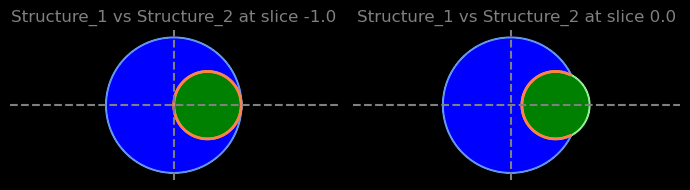

In [28]:
# Create figure and plot
fig, ax = plt.subplots(1, 2, figsize=(7, 2))
slice_idx = -1.0
plot_roi_slice(structure_set, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[0], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 0.0
plot_roi_slice(structure_set, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[1], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()


-1.4<br>
**Confines**<br>
`011 111 111`<br>
`111 001 001`<br>
`111 001 001`<br>

-1.2<br>
**Borders**<br>
`011 011 111`<br>
`111 111 001`<br>
`111 111 001`<br>

-1.4 | -1.2<br>
*cumulative*<br>
`011 111 111`<br>
`111 111 001`<br>
`111 111 001`<br>



**BORDERS**<br>
*pattern*<br>
`F** F*T ***`<br>
`*T* *** ***`<br>
`*** T** ***`<br>

**CONFINES**<br>
*pattern*<br>
`F** T*T ***`<br>
`*T* *** ***`<br>
`*** F** ***`<br>

**CONFINED**<br>
*pattern*<br>
`F** T*F ***`<br>
`*T* *** ***`<br>
`*** T** ***`<br>


"relation_type": "CONTAINS",
"label": "Contains",
"pattern": "TT*FF*F**\tT********\tT********",
"mask": "0b110110100100000000100000000",
"value": "0b110000000100000000100000000",


"relation_type": "OVERLAPS",
"label": "Overlaps",
"pattern": "T*****T**\tT********\tT********",
"mask": "0b100000100100000000100000000",
"value": "0b100000100100000000100000000",


**Confines Matrix***

011 111 111<br>
111 001 001<br>
111 001 001<br>

**Shelters Matrix**

001 001 111<br>
001 001 001<br>
111 111 001<br>

**Combined Matrix**

011 111 111<br>
111 001 001<br>
111 111 001<br>

**DISJOINT**
```
F** **T **T
*F* *** ***
*** T** T**
```

**mask**

100 001 001<br>
010 100 000<br>
000 100 100<br>

**value**

000 001 001<br>
000 000 000<br>
000 001 001<br>


### 5b) Visualize contours with plot_ab

ValueError: structure_set must have dicom_structure_file to use structure_names

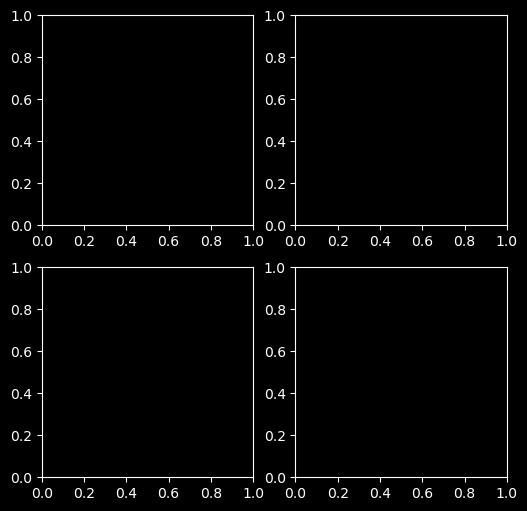

In [29]:
# Create figure and plot
fig, ax = plt.subplots(2, 2, figsize=(6, 6))
slice_idx = -1.5
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[0, 0], tolerance=0.1,
               plot_mode='relationship')
slice_idx = -1.4
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[0, 1], tolerance=0.1,
               plot_mode='relationship')
slice_idx = -1.3
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[1, 0], tolerance=0.1,
               plot_mode='relationship')
slice_idx = -1.2
plot_roi_slice(structure_set, slice_index=slice_idx,
               structure_names=[target_a_name, target_b_name],
               add_axis=True, axes=ax[1, 1], tolerance=0.1,
               plot_mode='relationship')

plt.tight_layout()
plt.show()

print('\n🔍 Plot Legend:')
print(f'  Blue area: Only in A ({target_a_name})')
print(f'  Green area: Only in B ({target_b_name})')
print('  Orange area: Intersection (both A and B)')
print('  Gray dashed lines: Origin (X=0, Y=0)')

## Handling Different Relationships for Different Regions 

Currently The only scenario that has been explicitly addressed is where there 
is a structure that is both *Surrounded* and *Disjoint*.  We declared that the 
over all relationship wad *Disjoint*, which overrode the surround portion.  
Here we have a *Confines* and *Shelters* combination.  In this case it would be 
useful to recognize the distinct relationships for the two regions.  

First we will summarize the ways in which relationships can be combined and 
transformed when there is only one region in each structure.  Then we will 
extend the analysis to consider how to handle multiple regions in each 
structure.

## Relationship Combinations and Transformations

### Relationships that cannot co-exist
What are impossible combinations when both structures have only one region?
- DISJOINT + SURROUNDS, or CONFINES
- SHELTERS + SURROUNDS, or CONFINES

A continuous region cannot have a portion that is disjoint or sheltering and a 
portion that is surrounding or confined.  A continuous region would have to be 
present in the volume that defines the hole surrounding the inner part.

All other relationships that occur on different regions of the same structure 
can be consolidated using the DE27IM bitwise OR operation.  However the above 
relationship combinations cannot be consolidated because they cannot be present 
in the same volume.  The results is an UNKNOWN relationship.

- Any combination of relationships is possible when one of the structures has 
more than one distinct region.

### Relationships that override others
As individual slice relationships are combined, one relationship will override 
another.

- OVERLAPS + ALL OTHERS -> OVERLAPS, 
- DISJOINT + SHELTERS -> DISJOINT, 
- BORDERS + SHELTERS, or DISJOINT -> BORDERS, 
- CONFINES + SURROUNDS -> CONFINES, 
- PARTITIONED + CONTAINS, or EQUAL -> PARTITIONED, 

There are also situations where relationship combinations can result in a third 
type of relationship:
- DISJOINT + PARTITIONED, CONTAINS, or EQUAL -> OVERLAPS,
- SURROUNDS + PARTITIONED, CONTAINS, or EQUAL -> OVERLAPS,
- EQUAL + CONTAINS -> PARTITIONED, 

### Boundary Effects
On boundary slices the relationship will always be UNKNOWN because they only 
include boundary interactions.  
These relationships can result in the following conversions:

If a boundary interaction is present, the relationship will be changed as 
follows:
- SHELTERS or DISJOINT -> BORDERS,
- CONTAINS -> PARTITIONED, 
- SURROUNDS -> CONFINES, 

In this case if a boundary interaction is NOT present, the relationship will be 
changed as follows:
- EQUAL -> CONTAINS

### Complementary Relationships
For all of the above patterns, changing the relationships to their complements 
will also result in a valid pattern.  
For example: 
- CONTAINS + EQUAL -> PARTITIONED
- WITHIN + EQUAL -> PARTITIONS


## Multiple Regions in Each Structure

As noted above, in most cases it will make sense to consolidate the 
relationships between multiple regions into a single relationship between the 
two structures using the same rules that are used to consolidate the 
relationships on each slice into a relationship between regions.  However, there 
are a few exceptions to this. When one region is disjoint or shelters and the 
other region is surrounding or confined, the overall relationship cannot be 
described using the DE27IM bitwise OR operation.  


### Reporting Relationships

- Continue to use the DE27IM bitwise OR operation to consolidate relationships 
between multiple regions into a single relationship between the two structures. 

- When all of the relationships between the different regions are identical, 
treat the overall relationship as if it were a single region with that 
relationship.

- When one or both of the structures has multiple regions, the relationships 
between the regions of the two structures are not the same, and the the DE27IM 
of the consolidated relationship can be associated with a named relationship 
(i.e. is not UNKNOWN), then add '{}' brackets around the relationship label 
to indicate that there are multiple relationships between the two structures.  

- If the DE27IM of the consolidated relationship is UNKNOWN, then report the 
overall relationship by combining the labels of the different relationships 
with a '&' symbol and add '{}' brackets around the combined label to indicate 
that there are multiple relationships between the two structures.

- Add a toggle to show a single relationship per structure, or an expanded 
    reporting of the relationships for multiple regions.



### Reporting Relationships for Multiple Regions
When there are multiple regions for a given structure there will be multiple 
relationships stored for that structure and another structure.  If the other 
structure also has multiple regions, the number of relationships can quickly 
become unmanageable for display purposes.  We will need to decide on some rules 
for how to consolidate these relationships for reporting purposes. 

1. If all relationships are the same, report that relationship
2. Otherwise:
    1. Count the number of relationships of each type.
    3. Sort the relationships by rank and then by count.
    4. Report the relationships in the following format:
        > {n_1} {relationship_1} Regions<br>        
        > {n_2} {relationship_2} Regions

        **Rank**
        1. EQUAL
        2. PARTITIONED
        3. PARTITIONS
        4. CONTAINS
        5. WITHIN
        6. CONFINES
        7. CONFINED
        8. SURROUNDS
        9. ENCLOSED
        10. BORDERS
        11. SHELTERS
        12. SHELTERED
        13. OVERLAPS
        14. DISJOINT

5. Include an option to drop any DISJOINT relationships.
6. Include an option to drop any OVERLAPS relationships.



### Future Considerations
- How to we take future metrics into account?  
- A given metric might be meaningful for one relationship and meaningless for 
    another.
- If there are two relationships which is the most important one to report? 
    i.e. should the case of *Surrounds* and *Disjoint* actually be reported as 
    *Surrounds* rather than *Disjoint*?
- Consider the possibility of created display nodes for each region in the 
    structure and then grouping them with an oval.  There would then be a toggle 
    to switch between displaying individual regions and the entire structure as 
    one node?  
- For now, continue with the current incremental labeling of regions. In the 
    future, explore using relational designators for different regions. 
    For example, Left and Right Lung, or Superior and Inferior PTV.  This would 
    be more meaningful to users and would also be more consistent with the way 
    that structures are currently named.  It would also allow for more 
    meaningful reporting of relationships and metrics.  

## TODO:
- Currently the code calculates the relationship for each slice based on the 
    union of all regions in each structure. In order to accurately deal with 
    relationships between structures where there are multiple regions in one or 
    both structures it will be necessary to modify this so that the relationship 
    is calculated and stored for each region on each slice.  The slice-by-slice 
    relationships for each region can then be consolidated to identify distinct 
    relationships for distinct regions.  It will also be necessary to modify 
    the relationship graph so that there are edges for each region's 
    relationship rather than just one edge for the overall relationship between 
    the two structures.

- This code modification will also require a change in the data structure. 
    Before making any cde modifications, Update the previous review of the data 
    structure and process to decide if it is still appropriate.  
    
- The following things need to be considered:
    - The relationship graph type needs to be changed to allow for multiple 
        edges (relationships) between the same two nodes (structures).
    - Is the Region table still a useful construct? Should it be modified or 
        replaced?
    - We currently store the relationship between structures for each slice. We 
        will now need to store the relationship between each region of each 
        structure for each slice.  What type of data structure will be best for 
        storing and accessing this data?
    - We will need a new method / function to summarize and display the 
        relationship(s) between structures.  I will want this accessible to the 
        future API, not just in the webapp.  Where should it be stored? In 
        structure_set.py in relations.py or in a new file?

    - In addition to current goals, future plans also need to be considered.

- Build some test cases that will cover the different possibilities.
    - The tests do not have to pass initially and the expected result can 
        change as the plan develops.
    - Start with a notebook so that the thinking process can be placed 
        alongside the tests

- Allow the Metrics development to proceed in parallel because the two will be 
    related.
    - Clearly document what metrics apply to what relationships
    - Look for cases where a change in relationship in the same region might 
        make the metric definition ambiguous.
    - Consider when and how metrics for different regions can be practically 
        consolidated.
    - Asses the impact of any change in relationship definitions on metric 
        definitions.